# Proyecto Glassdoor: inicio

Solo entorno e importaciones. Instala requirements.txt según el README y selecciona el kernel correcto. No se carga ningún modelo ni se ejecutan análisis.

In [1]:
import time

inicio_notebook = time.perf_counter()

## 1. Comprobar el entorno

In [2]:
import sys
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

print("Python:", sys.version.split()[0])
print("Ejecutable:", sys.executable)
paquetes = [
    "numpy", "pandas", "scipy", "pyarrow", "openpyxl", "matplotlib",
    "seaborn", "plotly", "wordcloud", "jinja2", "torch", "transformers",
    "sentence-transformers", "bertopic", "umap-learn", "hdbscan",
    "scikit-learn", "nltk", "jupyterlab", "ipykernel", "ipywidgets",
    "nbformat", "tqdm", "joblib"
]
faltantes = []
for paquete in paquetes:
    try:
        print(f"{paquete}: {version(paquete)}")
    except PackageNotFoundError:
        faltantes.append(paquete)
if faltantes:
    raise RuntimeError(
        "Faltan: " + ", ".join(faltantes)
        + ". Instala requirements.txt en este entorno y reinicia el kernel."
    )


Python: 3.11.9
Ejecutable: c:\Users\ALEX\Desktop\DataWorksapce\ML\ProjectNLP-Nortes_Alejandro\.venv-glassdoor\Scripts\python.exe
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
pyarrow: 23.0.1
openpyxl: 3.1.5
matplotlib: 3.11.2
seaborn: 0.13.2
plotly: 6.9.0
wordcloud: 1.9.6
jinja2: 3.1.6
torch: 2.14.1
transformers: 4.57.6
sentence-transformers: 5.7.0
bertopic: 0.17.4
umap-learn: 0.5.12
hdbscan: 0.8.44
scikit-learn: 1.7.2
nltk: 3.10.3
jupyterlab: 4.6.4
ipykernel: 7.4.0
ipywidgets: 8.1.9
nbformat: 5.11.1
tqdm: 4.70.1
joblib: 1.6.0


## 2. Importaciones

La primera importación de BERTopic y UMAP puede tardar. Se usa PyTorch para NLP.

In [3]:
import os
import re
import json
import random
from collections import Counter

# Ejecutar antes de importar transformers.
os.environ["USE_TF"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Datos y gráficos
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
from IPython.display import display

# NLP y sentimiento
import torch
import nltk
from transformers import pipeline, AutoTokenizer
from sentence_transformers import SentenceTransformer

# Topic modeling
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Persistencia y progreso
import joblib
from tqdm.auto import tqdm

print("Importaciones completadas.")


Importaciones completadas.


## 3. Configuración

La semilla ayuda a repetir experimentos, pero no garantiza igualdad en cualquier equipo. Los modelos solo se nombran; no se descargan.

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DISPOSITIVO = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_PIPELINE = 0 if DISPOSITIVO == "cuda" else -1
MODELO_SENTIMIENTO = "distilbert-base-uncased-finetuned-sst-2-english"
MODELO_EMBEDDINGS = "sentence-transformers/all-MiniLM-L6-v2"
MAX_POR_EMPRESA = 2000

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 13})
print("Dispositivo:", DISPOSITIVO)
if DISPOSITIVO == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Dispositivo: cpu


## 4. Rutas

Abre el notebook desde la carpeta descomprimida o modifica BASE_DIR. Copia los archivos del profesor en data/. Todavía no se eligen empresas ni se cargan datos.

In [ ]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
""" OUTPUT_DIR = BASE_DIR / "resultados"
MODELS_DIR = BASE_DIR / "modelos" """
for carpeta in (DATA_DIR): # , OUTPUT_DIR, MODELS_DIR
    carpeta.mkdir(parents=True, exist_ok=True)

RUTA_RESEÑAS = DATA_DIR / "glassdoor_reviews_hr.parquet"
RUTA_EMPRESAS = DATA_DIR / "lista_con_sector.xlsx"
print("Carpeta de trabajo:", BASE_DIR)
for ruta in (RUTA_RESEÑAS, RUTA_EMPRESAS):
    estado = "Disponible" if ruta.is_file() else "Pendiente de copiar en data/"
    print(f"{ruta.name}: {estado}")


Carpeta de trabajo: c:\Users\ALEX\Desktop\DataWorksapce\ML\ProjectNLP-Nortes_Alejandro
glassdoor_reviews_hr.parquet: Disponible
lista_con_sector.xlsx: Disponible


# Diagnóstico de marca empleadora: Deutsche Bank

Analizamos las reseñas de Glassdoor para identificar fortalezas y áreas
de mejora de Deutsche Bank como empleador, comparándolo con J.P. Morgan,
Barclays, Citi y HSBC.

Son bancos internacionales con actividades de banca corporativa y de
inversión que compiten por perfiles financieros, tecnológicos y de
operaciones. La comparación tendrá en cuenta las posibles diferencias
entre países y áreas de negocio.

El objetivo es priorizar hasta tres acciones concretas para RRHH,
respaldadas por las reseñas y por la comparación con los competidores.

In [6]:
# Empresa principal y competidores
TARGET = "Deutsche-Bank"

PEERS = [
    "J.P.-Morgan",
    "Barclays",
    "Citi",
    "HSBC"
]

FIRMS = [TARGET] + PEERS

# Comprobamos su presencia en el listado del profesor
lista_empresas = pd.read_excel(RUTA_EMPRESAS)

seleccion_empresas = (
    lista_empresas.loc[
        lista_empresas["firm"].isin(FIRMS),
        ["firm", "count", "sector"]
    ]
    .sort_values("count", ascending=False)
    .rename(columns={
        "firm": "Empresa",
        "count": "Reseñas disponibles",
        "sector": "Sector"
    })
)

display(seleccion_empresas)

faltantes = set(FIRMS) - set(lista_empresas["firm"])

if faltantes:
    print("Revisar estos nombres:", sorted(faltantes))
else:
    print("Las cinco empresas están disponibles.")

,Empresa,Reseñas disponibles,Sector
38,Citi,14609,Banca
41,HSBC,13173,Banca
46,J.P.-Morgan,12033,Banca
62,Barclays,9863,Banca
139,Deutsche-Bank,5474,Banca


Las cinco empresas están disponibles.


## 1. Carga y revisión inicial de los datos

Cargamos las reseñas de Deutsche Bank y sus cuatro competidores.
Revisamos el volumen por empresa, el periodo disponible y las primeras
filas para comprobar que la carga es correcta.

In [7]:
# Leemos solo las empresas seleccionadas
raw = pd.read_parquet(
    RUTA_RESEÑAS,
    filters=[("firm", "in", FIRMS)]
)

# Conservamos raw como datos originales
df = raw.copy()

df["date_review"] = pd.to_datetime(
    df["date_review"],
    errors="coerce"
)

# Resumen de cobertura por empresa
resumen_carga = (
    df.groupby("firm")
    .agg(
        reseñas=("firm", "size"),
        primera_fecha=("date_review", "min"),
        ultima_fecha=("date_review", "max")
    )
    .reindex(FIRMS)
)

print(f"Total de reseñas cargadas: {len(df):,}")
print(f"Número de columnas: {df.shape[1]}")
print(f"Reseñas sin fecha válida: {df['date_review'].isna().sum():,}")

display(resumen_carga)
display(df.head(3))

Total de reseñas cargadas: 55,152
Número de columnas: 7
Reseñas sin fecha válida: 0


,reseñas,primera_fecha,ultima_fecha
firm,,,
Deutsche-Bank,5474,2018-07-27,2023-04-14
J.P.-Morgan,12033,2018-07-27,2023-03-14
Barclays,9863,2018-07-27,2023-03-20
Citi,14609,2018-07-27,2023-03-16
HSBC,13173,2018-07-27,2023-03-18


,firm,date_review,current,overall_rating,recommend,pros,cons
0,Barclays,2018-07-27,"Current Employee, more than 3 years",2.0,x,Dynamic working being rolled out across company\r\nBasic salary on the high side,No real direction or clear leadership\r\nOngoing battles with management over capacity / workloa...
1,Barclays,2018-07-27,"Former Employee, more than 1 year",4.0,v,Great atmosphere and people occasionally you have a few rotten apples but majority of the people...,"Need better managers to facilitate and orchestrate, not all are bad just need to be more aware o..."
2,Barclays,2018-07-28,"Current Employee, more than 1 year",5.0,v,Values of Barclays are outstanding. Cab facilities and maternity leaves are the biggest plus for...,Internal job movements are preferred based on know person than knowledged person.


## 2. Revisión de calidad de los datos

Comprobamos los valores ausentes, los textos vacíos y las reseñas
duplicadas, tanto en el conjunto completo como por empresa.

Esta revisión permite decidir qué registros pueden utilizarse en cada
análisis. Una reseña sin pros o cons puede seguir aportando información
sobre el rating, por lo que no eliminamos filas automáticamente.

In [8]:
display(
    df.isna()
    .sum()
    .rename("Cantidad de nulos")
    .to_frame()
)

print(f"Total de nulos: {df.isna().sum().sum():,}")

,Cantidad de nulos
firm,0
date_review,0
current,0
overall_rating,0
recommend,0
pros,0
cons,0


Total de nulos: 0


In [9]:
columnas_texto = ["firm", "current", "recommend", "pros", "cons"]

vacios = (
    df[columnas_texto]
    .astype("string")
    .apply(lambda columna: columna.str.strip().eq(""))
    .sum()
)

display(vacios.rename("Textos vacíos").to_frame())

,Textos vacíos
firm,0
current,0
recommend,0
pros,0
cons,0


No se detectan valores nulos ni textos vacíos en las variables analizadas.
Por tanto, no es necesario imputar ni eliminar registros por este motivo.

In [10]:
n_duplicados = df.duplicated().sum()

print(f"Duplicados exactos encontrados: {n_duplicados:,}")

if n_duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Se han eliminado {n_duplicados:,} filas duplicadas.")
else:
    print("No es necesario eliminar ninguna fila.")

print(f"Reseñas disponibles: {len(df):,}")

Duplicados exactos encontrados: 0
No es necesario eliminar ninguna fila.
Reseñas disponibles: 55,152


No se detectan valores nulos, textos vacíos ni duplicados exactos.
Por tanto, se conservan todas las reseñas para continuar el análisis.

In [11]:
# Ratings presentes que no son numéricos o están fuera de 1–5
rating_numerico = pd.to_numeric(df["overall_rating"], errors="coerce")

rating_invalido = (
    rating_numerico.isna()
    | ~rating_numerico.between(1, 5)
)

print(f"Ratings no válidos: {rating_invalido.sum():,}")

print("\nValores de recommend:")
display(df["recommend"].value_counts(dropna=False))

print("\nValores de current:")
display(df["current"].value_counts(dropna=False))

Ratings no válidos: 0

Valores de recommend:


recommend
v    25409
o    21632
x     8111
Name: count, dtype: int64


Valores de current:


current
Current Employee                        15253
Former Employee                          7395
Current Employee, more than 1 year       5599
Current Employee, more than 3 years      5064
Former Employee, more than 1 year        3866
Current Employee, more than 5 years      3223
Former Employee, more than 3 years       3044
Current Employee, less than 1 year       2843
Former Employee, more than 5 years       1803
Current Employee, more than 8 years      1769
Current Employee, more than 10 years     1711
Former Employee, less than 1 year        1615
Former Employee, more than 10 years       985
Former Employee, more than 8 years        982
Name: count, dtype: int64

Los ratings son válidos y las categorías coinciden con lo esperado.

### 2.1 Preparación de variables

Todos los ratings son numéricos y están dentro del intervalo de 1 a 5.

Separamos la situación laboral y la antigüedad, originalmente combinadas
en `current`. Cuando no se indica antigüedad, la etiquetamos como
«No especificada».

Traducimos `recommend` a «Sí», «No» y «Sin opinión», manteniendo esta
última como una respuesta distinta de las otras dos.

In [12]:
# Situación laboral
df["situacion"] = (
    df["current"]
    .str.split(",", n=1)
    .str[0]
    .str.strip()
    .map({
        "Current Employee": "Actual",
        "Former Employee": "Antiguo"
    })
)

# Antigüedad: conservamos las categorías tal como están declaradas
mapa_antiguedad = {
    "less than 1 year": "Menos de 1 año",
    "more than 1 year": "Más de 1 año",
    "more than 3 years": "Más de 3 años",
    "more than 5 years": "Más de 5 años",
    "more than 8 years": "Más de 8 años",
    "more than 10 years": "Más de 10 años"
}

df["antiguedad"] = (
    df["current"]
    .str.split(",", n=1)
    .str[1]
    .str.strip()
    .map(mapa_antiguedad)
    .fillna("No especificada")
)

# Recomendación
df["recomienda"] = df["recommend"].map({
    "v": "Sí",
    "o": "Sin opinión",
    "x": "No"
})

# Año para estudiar la evolución temporal
df["anio"] = df["date_review"].dt.year

display(
    df[["current", "situacion", "antiguedad", "recomienda"]]
    .head(10)
)

print("Situación laboral:")
display(df["situacion"].value_counts())

print("Antigüedad:")
display(df["antiguedad"].value_counts())

,current,situacion,antiguedad,recomienda
0,"Current Employee, more than 3 years",Actual,Más de 3 años,No
1,"Former Employee, more than 1 year",Antiguo,Más de 1 año,Sí
2,"Current Employee, more than 1 year",Actual,Más de 1 año,Sí
3,"Current Employee, more than 1 year",Actual,Más de 1 año,No
4,"Former Employee, less than 1 year",Antiguo,Menos de 1 año,Sí
5,Current Employee,Actual,No especificada,Sin opinión
6,"Current Employee, more than 1 year",Actual,Más de 1 año,Sin opinión
7,"Current Employee, more than 5 years",Actual,Más de 5 años,Sí
8,Current Employee,Actual,No especificada,Sin opinión
9,Current Employee,Actual,No especificada,Sí


Situación laboral:


situacion
Actual     35462
Antiguo    19690
Name: count, dtype: int64

Antigüedad:


antiguedad
No especificada    22648
Más de 1 año        9465
Más de 3 años       8108
Más de 5 años       5026
Menos de 1 año      4458
Más de 8 años       2751
Más de 10 años      2696
Name: count, dtype: int64

In [13]:
n_actuales = df["situacion"].eq("Actual").sum()
n_antiguos = df["situacion"].eq("Antiguo").sum()
n_sin_antiguedad = df["antiguedad"].eq("No especificada").sum()
pct_sin_antiguedad = n_sin_antiguedad / len(df) * 100

print(
    f"Tenemos {n_actuales:,} empleados actuales y "
    f"{n_antiguos:,} antiguos. Además, "
    f"{n_sin_antiguedad:,} reseñas ({pct_sin_antiguedad:.1f} %) "
    "no especifican antigüedad; las conservamos."
)

Tenemos 35,462 empleados actuales y 19,690 antiguos. Además, 22,648 reseñas (41.1 %) no especifican antigüedad; las conservamos.


## 3. Análisis exploratorio

### 3.1 Comparación general entre empresas

Comparamos el volumen de reseñas, el rating medio, la recomendación
y la proporción de empleados actuales y antiguos.

El porcentaje de recomendación se calcula sobre todas las reseñas de
cada empresa. Mostramos también las respuestas «Sin opinión» para
interpretar correctamente las diferencias.

In [14]:
resumen_empresas = (
    df.groupby("firm")
    .agg(
        reseñas=("firm", "size"),
        rating_medio=("overall_rating", "mean"),
        recomienda_pct=("recomienda", lambda s: s.eq("Sí").mean()),
        no_recomienda_pct=("recomienda", lambda s: s.eq("No").mean()),
        sin_opinion_pct=("recomienda", lambda s: s.eq("Sin opinión").mean()),
        actuales_pct=("situacion", lambda s: s.eq("Actual").mean()),
        antiguos_pct=("situacion", lambda s: s.eq("Antiguo").mean())
    )
    .reindex(FIRMS)
)

display(
    resumen_empresas.style.format({
        "reseñas": "{:,.0f}",
        "rating_medio": "{:.2f}",
        "recomienda_pct": "{:.1%}",
        "no_recomienda_pct": "{:.1%}",
        "sin_opinion_pct": "{:.1%}",
        "actuales_pct": "{:.1%}",
        "antiguos_pct": "{:.1%}"
    })
)

,reseñas,rating_medio,recomienda_pct,no_recomienda_pct,sin_opinion_pct,actuales_pct,antiguos_pct
firm,,,,,,,
Deutsche-Bank,"5,474",3.73,43.4%,17.8%,38.7%,63.0%,37.0%
J.P.-Morgan,"12,033",4.01,49.9%,10.4%,39.7%,64.9%,35.1%
Barclays,"9,863",3.89,48.0%,13.7%,38.3%,65.9%,34.1%
Citi,"14,609",3.78,45.7%,16.0%,38.3%,66.5%,33.5%
HSBC,"13,173",3.74,42.6%,16.7%,40.7%,60.6%,39.4%


**Interpretación:**

Deutsche Bank presenta el menor rating medio del grupo (3,73),
frente a aproximadamente 3,86 de media entre sus cuatro competidores,
dando igual peso a cada banco. La diferencia con HSBC (3,74) es mínima.

El 43,4 % de sus reseñas recomienda la empresa, frente al 46,6 %
medio de los peers. Solo HSBC presenta un porcentaje inferior.
Además, Deutsche Bank registra el mayor porcentaje de respuestas
«No» (17,8 %).

El 38,7 % de respuestas sin opinión no debe interpretarse como rechazo.
También tendremos en cuenta las diferencias en la proporción de
empleados actuales y antiguos.

**Implicación para RRHH:** investigar qué aspectos de las reseñas
explican esta desventaja y contrastarlos con los peers antes de
priorizar acciones de mejora.

### 3.2 Evolución temporal del rating

Analizamos cómo evoluciona el rating medio de Deutsche Bank frente
a sus competidores. La referencia es la media de los ratings anuales
de los cuatro peers, dando igual peso a cada banco.

Revisamos también el volumen anual de reseñas. Los años 2018 y 2023
tienen cobertura parcial en el dataset, por lo que sus resultados
no representan años completos.

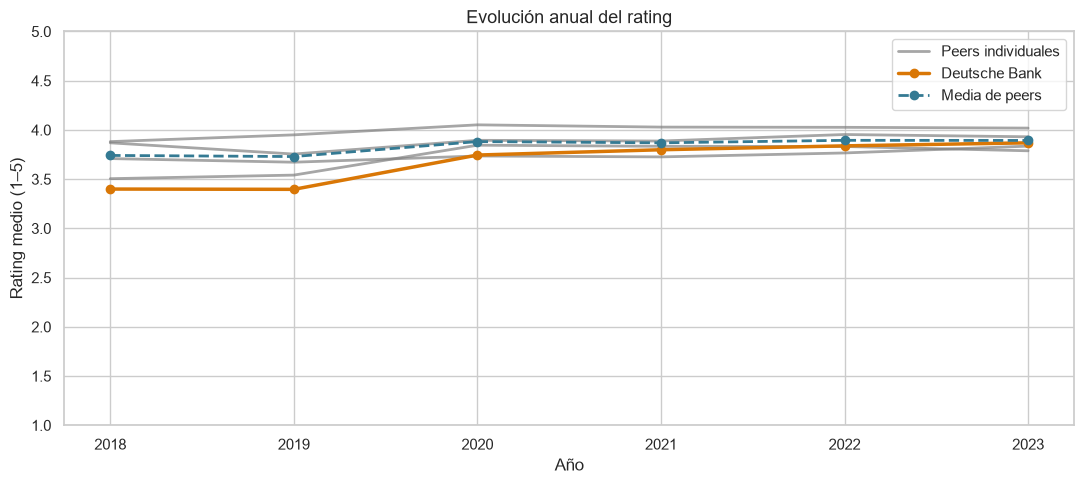

,Rating Deutsche Bank,Rating medio peers,Diferencia de rating,Reseñas Deutsche Bank
anio,,,,
2018,3.40,3.74,-0.34,303
2019,3.40,3.73,-0.33,749
2020,3.74,3.88,-0.14,866
2021,3.80,3.87,-0.07,"1,639"
2022,3.84,3.89,-0.06,"1,551"
2023,3.87,3.89,-0.02,366


Número de reseñas por año y empresa:


firm,Deutsche-Bank,J.P.-Morgan,Barclays,Citi,HSBC
anio,,,,,
2018,303,732,420,630,591
2019,749,1859,1359,1654,1787
2020,866,2167,1593,2030,2168
2021,1639,4456,3254,4739,3932
2022,1551,2605,2706,4655,3984
2023,366,214,531,901,711


In [15]:
# Rating medio y volumen de reseñas por año y empresa
rating_anual = (
    df.groupby(["anio", "firm"])["overall_rating"]
    .mean()
    .unstack("firm")
    .reindex(columns=FIRMS)
    .sort_index()
)

volumen_anual = (
    pd.crosstab(df["anio"], df["firm"])
    .reindex(columns=FIRMS, fill_value=0)
    .sort_index()
)

# Igual peso para cada peer.
# Solo calculamos la referencia si están presentes los cuatro.
media_peers_anual = rating_anual[PEERS].mean(
    axis=1,
    skipna=False
)

fig, ax = plt.subplots(figsize=(11, 5))

# Peers individuales como contexto
for i, empresa in enumerate(PEERS):
    ax.plot(
        rating_anual.index,
        rating_anual[empresa],
        color="gray",
        alpha=0.7,
        linewidth=2,
        label="Peers individuales" if i == 0 else None
    )

ax.plot(
    rating_anual.index,
    rating_anual[TARGET],
    marker="o",
    linewidth=2.5,
    color="#D97706",
    label="Deutsche Bank"
)

ax.plot(
    media_peers_anual.index,
    media_peers_anual,
    marker="o",
    linestyle="--",
    linewidth=2,
    color="#347A93",
    label="Media de peers"
)

ax.set_title("Evolución anual del rating")
ax.set_xlabel("Año")
ax.set_ylabel("Rating medio (1–5)")
ax.set_xticks(rating_anual.index)
ax.set_ylim(1, 5)
ax.legend()

plt.tight_layout()
plt.show()

# Tabla para interpretar el gráfico con cifras
comparacion_anual = pd.DataFrame({
    "Rating Deutsche Bank": rating_anual[TARGET],
    "Rating medio peers": media_peers_anual,
    "Diferencia de rating": (
        rating_anual[TARGET] - media_peers_anual
    ),
    "Reseñas Deutsche Bank": volumen_anual[TARGET]
})

display(
    comparacion_anual.style.format({
        "Rating Deutsche Bank": "{:.2f}",
        "Rating medio peers": "{:.2f}",
        "Diferencia de rating": "{:+.2f}",
        "Reseñas Deutsche Bank": "{:,.0f}"
    })
)

print("Número de reseñas por año y empresa:")
display(volumen_anual)

**Interpretación y acción:**

El rating de Deutsche Bank aumenta de 3,40 en 2018 a 3,87 en 2023.
La distancia respecto a la media de los peers se reduce de 0,34 a
0,02 puntos, aunque sigue por debajo durante todos los años analizados.

Los extremos del periodo tienen cobertura parcial y 2023 incluye
solo 366 reseñas de Deutsche Bank, por lo que interpretamos la
convergencia con cautela.

Para RRHH, conviene identificar qué fortalezas acompañan esta mejora
y qué quejas persisten en los años recientes, antes de priorizar acciones.

### 3.3 Rating según situación laboral

Comparamos el rating de empleados actuales y antiguos dentro de cada
banco para comprobar si la desventaja de Deutsche Bank aparece en
ambos grupos. Las diferencias describen las reseñas y no demuestran
los motivos de salida.

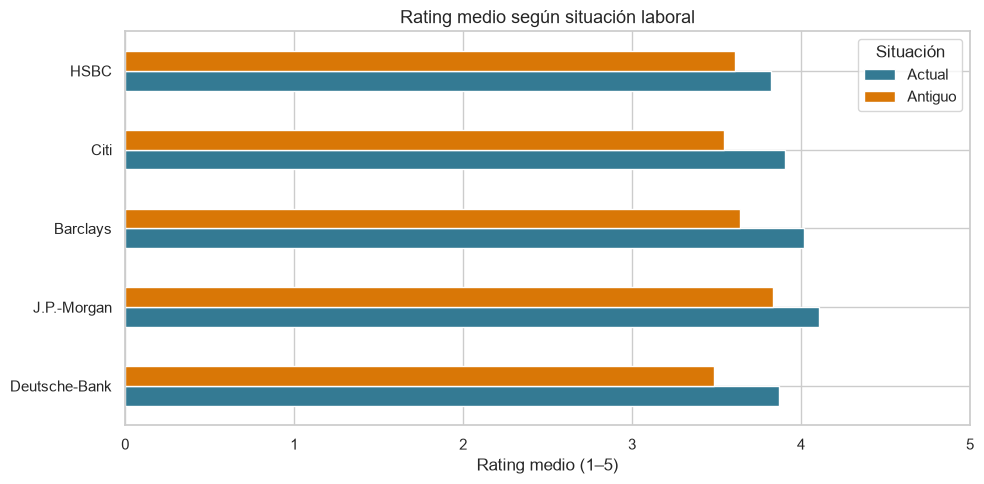

In [16]:
resumen_situacion = (
    df.groupby(["firm", "situacion"])
    .agg(
        reseñas=("overall_rating", "size"),
        rating_medio=("overall_rating", "mean")
    )
)

display(
    resumen_situacion.style.format({
        "reseñas": "{:,.0f}",
        "rating_medio": "{:.2f}"
    })
)

rating_situacion = (
    resumen_situacion["rating_medio"]
    .unstack("situacion")
    .reindex(index=FIRMS, columns=["Actual", "Antiguo"])
)

ax = rating_situacion.plot.barh(
    figsize=(10, 5),
    color=["#347A93", "#D97706"]
)

ax.set_title("Rating medio según situación laboral")
ax.set_xlabel("Rating medio (1–5)")
ax.set_ylabel("")
ax.set_xlim(0, 5)
ax.legend(title="Situación")

plt.tight_layout()
plt.show()

**Interpretación y acción:**

Los antiguos empleados puntúan más bajo que los actuales en los cinco
bancos. En Deutsche Bank, el rating pasa de 3,87 entre actuales a 3,49
entre antiguos: una diferencia de 0,38 puntos.

Deutsche Bank presenta el menor rating entre antiguos empleados.
Entre los actuales, solo supera a HSBC. Por tanto, su posición
desfavorable también aparece al comparar por situación laboral.

**Implicación para RRHH:** analizar qué quejas destacan los antiguos
empleados de Deutsche Bank frente a los de sus competidores y comprobar
si también aparecen entre los actuales. Esto permitirá identificar
posibles prioridades de retención, sin asumir que las reseñas demuestran
los motivos de salida.

## 4. Análisis de sentimiento en pros y cons

Utilizaremos un transformer preentrenado para comprobar si los pros
se clasifican principalmente como positivos y los cons como negativos.
Revisaremos manualmente ejemplos que no coincidan con lo esperado.

### 4.1 Muestra para NLP

Seleccionamos hasta 2.000 reseñas por empresa, con semilla fija y
un reparto proporcional por año. Esto limita el tiempo de procesamiento
y equilibra la representación de los bancos.

El EDA conserva todos los registros; la muestra se guarda por separado.

In [17]:
muestras = []

for empresa in FIRMS:
    datos_empresa = df.loc[df["firm"].eq(empresa)]

    # Tamaño total que queremos seleccionar para este banco
    n_muestra = min(MAX_POR_EMPRESA, len(datos_empresa))

    # Distribuimos la muestra proporcionalmente entre sus años
    recuentos = datos_empresa.groupby("anio").size()
    cuotas = recuentos / recuentos.sum() * n_muestra
    cantidades = np.floor(cuotas).astype(int)

    # Repartimos los registros restantes por los mayores decimales
    restantes = n_muestra - cantidades.sum()

    if restantes > 0:
        años_extra = (
            (cuotas - cantidades)
            .sort_values(ascending=False)
            .head(restantes)
            .index
        )
        cantidades.loc[años_extra] += 1

    for anio, cantidad in cantidades.items():
        muestra_anual = (
            datos_empresa.loc[datos_empresa["anio"].eq(anio)]
            .sample(n=int(cantidad), random_state=SEED)
        )
        muestras.append(muestra_anual)

# Conservamos el índice original para identificar cada reseña
df_nlp = pd.concat(muestras).copy()

# Limpieza ligera: mantenemos mayúsculas, puntuación y negaciones
for columna in ["pros", "cons"]:
    df_nlp[columna] = (
        df_nlp[columna]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

print(f"Reseñas seleccionadas: {len(df_nlp):,}")
print(f"Textos para sentimiento: {len(df_nlp) * 2:,}")

display(
    pd.crosstab(df_nlp["firm"], df_nlp["anio"])
    .reindex(FIRMS)
)

Reseñas seleccionadas: 10,000
Textos para sentimiento: 20,000


anio,2018,2019,2020,2021,2022,2023
firm,,,,,,
Deutsche-Bank,111,273,316,599,567,134
J.P.-Morgan,122,309,360,741,433,35
Barclays,85,275,323,660,549,108
Citi,86,227,278,649,637,123
HSBC,90,271,329,597,605,108


### 4.2 Carga del modelo y prueba inicial

Utilizamos DistilBERT ajustado para clasificar sentimiento en inglés.
Devuelve dos etiquetas: positivo y negativo, sin categoría neutral.

Probamos primero 50 pros y 50 cons. Los textos que superen el límite
del modelo se truncarán a 512 tokens. La puntuación del modelo indica
su confianza en la etiqueta, no la intensidad del sentimiento.

In [18]:
from time import perf_counter

dispositivo = 0 if torch.cuda.is_available() else -1

analizador_sentimiento = pipeline(
    task="sentiment-analysis",
    model=MODELO_SENTIMIENTO,
    tokenizer=MODELO_SENTIMIENTO,
    framework="pt",
    device=dispositivo
)

print("Modelo cargado.")
print("Dispositivo:", "GPU" if dispositivo == 0 else "CPU")

Device set to use cpu


Modelo cargado.
Dispositivo: CPU


In [19]:
# Seleccionamos las mismas 50 reseñas para probar pros y cons
muestra_prueba = df_nlp.sample(n=50, random_state=SEED)

prueba = (
    muestra_prueba[["firm", "pros", "cons"]]
    .melt(
        id_vars="firm",
        value_vars=["pros", "cons"],
        var_name="tipo",
        value_name="texto"
    )
)

BATCH_SIZE = 16 if dispositivo == 0 else 8

# Calentamiento: lo dejamos fuera de la medición
_ = analizador_sentimiento(
    ["The team is supportive."],
    truncation=True,
    max_length=512
)

inicio = perf_counter()

predicciones = analizador_sentimiento(
    prueba["texto"].tolist(),
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=512
)

segundos = perf_counter() - inicio

prueba["sentimiento"] = [p["label"] for p in predicciones]
prueba["confianza"] = [p["score"] for p in predicciones]

print(f"Textos procesados: {len(prueba)}")
print(f"Tiempo: {segundos:.1f} segundos")

minutos_estimados = (
    segundos / len(prueba) * (len(df_nlp) * 2) / 60
)

print(
    f"Estimación orientativa para toda la muestra: "
    f"{minutos_estimados:.1f} minutos"
)

# Mostramos ejemplos de ambos campos
display(
    prueba.groupby("tipo", sort=False)
    .head(5)
    .style.format({"confianza": "{:.3f}"})
)

Textos procesados: 100
Tiempo: 1.9 segundos
Estimación orientativa para toda la muestra: 6.3 minutos


,firm,tipo,texto,sentimiento,confianza
0,Citi,pros,Healthcare and Benefits Opportunity to learn,POSITIVE,1.000
1,Barclays,pros,You get the salary on 24th of every month,POSITIVE,0.816
2,Deutsche-Bank,pros,"Good place for work, stability and good internal culture",POSITIVE,1.000
3,Barclays,pros,"Opportunity to grow , technologically evolving bank",POSITIVE,1.000
4,Barclays,pros,Good work culture good environment,POSITIVE,1.000
50,Citi,cons,Hours expectation Relative pay to the street,NEGATIVE,0.956
51,Barclays,cons,"Oudated systems, extensive working hours",NEGATIVE,0.999
52,Deutsche-Bank,cons,"Good place, but a lot of work, not for rest )",POSITIVE,0.972
53,Barclays,cons,Its a great place to work,POSITIVE,1.000
54,Barclays,cons,I think it's one of the good companies to work with,POSITIVE,1.000


Antes de aplicar el modelo de sentimiento al conjunto completo de reseñas, se realiza una prueba sobre una muestra aleatoria de 50 observaciones. Para cada reseña se analizan por separado los campos pros y cons, por lo que se procesan un total de 100 textos.

Esta prueba permite comprobar el funcionamiento del modelo, observar ejemplos de las predicciones obtenidas y estimar el tiempo aproximado necesario para procesar el conjunto completo. Para cada texto, el modelo devuelve una etiqueta de sentimiento (POSITIVE o NEGATIVE) y una puntuación de confianza asociada a la predicción.

Además, se realiza un calentamiento previo del modelo que no se incluye en la medición del tiempo, con el objetivo de obtener una estimación más representativa del coste real de inferencia. Finalmente, se muestran algunos ejemplos de los resultados obtenidos tanto para pros como para cons.

### 4.3 Aplicación del modelo de sentimiento

Una vez validado el funcionamiento del modelo sobre una muestra reducida, se aplica el análisis de sentimiento al conjunto completo de reseñas. Los campos pros y cons se procesan por separado mediante un modelo transformer preentrenado.

Para evitar errores con textos largos, se utiliza truncation=True, ya que los modelos tipo BERT admiten un máximo de 512 tokens.

Como control de calidad, se calculará para cada empresa el porcentaje de pros clasificados como positivos y el porcentaje de cons clasificados como negativos. Dado el significado de ambos campos, se espera que la mayoría de los pros sean positivos y la mayoría de los cons sean negativos.

Finalmente, se revisará una muestra de casos discordantes —pros negativos y cons positivos— para identificar posibles problemas de ambigüedad, negación, ironía o interpretación contextual por parte del modelo.

In [20]:
pred_pros = analizador_sentimiento(
    df_nlp["pros"].tolist(),
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=512
)

df_nlp["sentimiento_pros"] = [p["label"] for p in pred_pros]
df_nlp["confianza_pros"] = [p["score"] for p in pred_pros]

pred_cons = analizador_sentimiento(
    df_nlp["cons"].tolist(),
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=512
)

df_nlp["sentimiento_cons"] = [p["label"] for p in pred_cons]
df_nlp["confianza_cons"] = [p["score"] for p in pred_cons]

Control de calidad por empresa

In [21]:
control_sentimiento = (
    df_nlp.groupby("firm")
    .agg(
        pct_pros_positivos=(
            "sentimiento_pros",
            lambda x: (x == "POSITIVE").mean()
        ),
        pct_cons_negativos=(
            "sentimiento_cons",
            lambda x: (x == "NEGATIVE").mean()
        )
    )
    .reindex(FIRMS)
)

display(
    control_sentimiento.style.format({
        "pct_pros_positivos": "{:.1%}",
        "pct_cons_negativos": "{:.1%}"
    })
)

,pct_pros_positivos,pct_cons_negativos
firm,,
Deutsche-Bank,92.5%,84.4%
J.P.-Morgan,94.2%,78.8%
Barclays,93.5%,79.8%
Citi,92.9%,82.2%
HSBC,94.3%,85.0%


Casos discordantes

In [22]:
pros_negativos = df_nlp[
    df_nlp["sentimiento_pros"] == "NEGATIVE"
][["firm", "pros", "sentimiento_pros", "confianza_pros"]]

cons_positivos = df_nlp[
    df_nlp["sentimiento_cons"] == "POSITIVE"
][["firm", "cons", "sentimiento_cons", "confianza_cons"]]

print("Pros clasificados como negativos:", len(pros_negativos))
print("Cons clasificados como positivos:", len(cons_positivos))

Pros clasificados como negativos: 653
Cons clasificados como positivos: 1795


Muestra de algunos ejemplos para ver que todo sale según lo esperado

In [23]:
display(
    pros_negativos.sample(
        min(10, len(pros_negativos)),
        random_state=SEED
    )
)

display(
    cons_positivos.sample(
        min(10, len(cons_positivos)),
        random_state=SEED
    )
)

,firm,pros,sentimiento_pros,confianza_pros
28657,Deutsche-Bank,"No pros whatsoever, pls. avoid",NEGATIVE,0.999766
1345,Barclays,Less intense working environment Friendly working environment,NEGATIVE,0.998860
50254,J.P.-Morgan,"Safe environment with lots of meetings, trying to become more agile but will always struggle wit...",NEGATIVE,0.992819
12357,Citi,None to think of at the moment,NEGATIVE,0.964729
16724,Citi,none are good now now,NEGATIVE,0.998615
16426,Citi,"There is no pros, they dont care about you development, they treat you like a robot",NEGATIVE,0.995069
2904,Barclays,"Salary wise quite decent Leave policies include maternity, paternity, bereavement as well Lots o...",NEGATIVE,0.991534
43220,J.P.-Morgan,Fast paced and pressured environment,NEGATIVE,0.974713
29081,Deutsche-Bank,"Do it yourself behavior, entrepeneurship",NEGATIVE,0.945338
1184,Barclays,They pay you well but there is a cost to it.,NEGATIVE,0.978174


,firm,cons,sentimiento_cons,confianza_cons
13020,Citi,"Long hours, and aggressive production goals.",POSITIVE,0.993950
29108,Deutsche-Bank,"good pay, great benefits and nice place to work",POSITIVE,0.999875
30931,HSBC,"Salaries, training, values experience management",POSITIVE,0.998051
46008,J.P.-Morgan,nothing bad to say at all,POSITIVE,0.996685
16825,Citi,Honestly cannot think of any.,POSITIVE,0.912159
3295,Barclays,Mostly no cons at all,POSITIVE,0.965771
53588,J.P.-Morgan,"not at all, just do smartwork",POSITIVE,0.996646
14415,Citi,"Salary could be more competitive; do not acquire leaders as managers, but tend to move people in...",POSITIVE,0.838978
8495,Barclays,No cons which I have experience,POSITIVE,0.994876
30606,HSBC,Small issues in general. Politics bound to have but still pleasant.,POSITIVE,0.997020


**Control de calidad del sentimiento:**

Entre el 92,5 % y el 94,3 % de los pros se clasifican como positivos,
y entre el 78,8 % y el 85,0 % de los cons como negativos. Estos valores
muestran concordancia con la orientación esperada de los campos,
pero no equivalen a la precisión del modelo.

La revisión encuentra discordancias justificadas: algunos pros
expresan que no existen ventajas y algunos cons indican que no hay
quejas. También aparecen errores claros, como clasificar positivamente
una queja sobre jornadas largas y objetivos exigentes, incluso con
confianza elevada.

Por tanto, utilizamos el sentimiento como control exploratorio.
Conservamos las reseñas discordantes y analizaremos sus temas según
el campo original, sin moverlas ni eliminarlas por la predicción.

Evitar perder las predicciones al cerrar el kernel

In [24]:
""" ruta_sentimiento = OUTPUT_DIR / "muestra_con_sentimiento.parquet"

df_nlp.to_parquet(
    ruta_sentimiento,
    index=True
)

print(f"Resultados guardados en: {ruta_sentimiento}") """

' ruta_sentimiento = OUTPUT_DIR / "muestra_con_sentimiento.parquet"\n\ndf_nlp.to_parquet(\n    ruta_sentimiento,\n    index=True\n)\n\nprint(f"Resultados guardados en: {ruta_sentimiento}") '

## 5. Identificación de temas con BERTopic

Utilizamos BERTopic para agrupar reseñas con contenido similar e
identificar los asuntos que los empleados destacan o critican.
Sus representaciones semánticas permiten relacionar textos aunque
utilicen palabras diferentes.

Entrenamos un modelo conjunto para los pros y otro para los cons,
incluyendo en ambos Deutsche Bank y sus cuatro competidores.
Esto permite comparar los mismos temas entre empresas.

### 5.1 Configuración inicial

Utilizamos el modelo de embeddings all-MiniLM-L6-v2, orientado a
textos en inglés y adecuado para trabajar con recursos limitados.

UMAP reduce las representaciones a cinco dimensiones. HDBSCAN
identifica grupos con un tamaño mínimo inicial de 50 textos, buscando
temas recurrentes que puedan orientar decisiones de RRHH.

Esta configuración es un punto de partida: revisaremos la coherencia
de los temas y la proporción de textos sin asignar antes de aceptarla.
No fijamos de antemano el número de temas.

In [25]:
# Comprobamos que los textos estén disponibles
for campo in ["pros", "cons"]:
    assert df_nlp[campo].notna().all(), f"Hay nulos en {campo}"
    assert df_nlp[campo].str.strip().ne("").all(), (
        f"Hay textos vacíos en {campo}"
    )

# Mantenemos el mismo orden que df_nlp
docs_pros = df_nlp["pros"].tolist()
docs_cons = df_nlp["cons"].tolist()

# Se descarga en la primera ejecución
modelo_embeddings = SentenceTransformer(
    MODELO_EMBEDDINGS,
    device=DISPOSITIVO
)

print("Dispositivo:", DISPOSITIVO)
print("Límite del encoder:", modelo_embeddings.max_seq_length, "tokens")

# Calculamos los vectores una vez para reutilizarlos si ajustamos BERTopic
embeddings_pros = modelo_embeddings.encode(
    docs_pros,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

embeddings_cons = modelo_embeddings.encode(
    docs_cons,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embeddings pros:", embeddings_pros.shape)
print("Embeddings cons:", embeddings_cons.shape)

Dispositivo: cpu
Límite del encoder: 256 tokens


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Embeddings pros: (10000, 384)
Embeddings cons: (10000, 384)


In [26]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Stopwords solo para las palabras que describen los topics.
# El encoder recibe el texto completo, sin quitar estas palabras.
# Conservamos negaciones que pueden ayudar a interpretar las expresiones.
stopwords_topics = sorted(
    set(ENGLISH_STOP_WORDS) - {"no", "not", "nor"}
)

def crear_modelo_topics():
    return BERTopic(
        embedding_model=modelo_embeddings,

        umap_model=UMAP(
            n_neighbors=15,
            n_components=5,
            min_dist=0.0,
            metric="cosine",
            random_state=SEED,
            n_jobs=1
        ),

        hdbscan_model=HDBSCAN(
            min_cluster_size=50,
            min_samples=10,
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=True
        ),

        vectorizer_model=CountVectorizer(
            stop_words=stopwords_topics,
            ngram_range=(1, 2),
            min_df=1
        ),

        top_n_words=10,
        calculate_probabilities=False,
        verbose=True
    )

In [27]:
modelo_topics_pros = crear_modelo_topics()

topics_pros, _ = modelo_topics_pros.fit_transform(
    docs_pros,
    embeddings=embeddings_pros
)

df_nlp["topic_pros"] = topics_pros

tabla_topics_pros = modelo_topics_pros.get_topic_info()

display(
    tabla_topics_pros[
        ["Topic", "Count", "Representation"]
    ]
)

2026-10-07 12:26:37,388 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-07 12:27:20,346 - BERTopic - Dimensionality - Completed ✓
2026-10-07 12:27:20,348 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-07 12:27:20,713 - BERTopic - Cluster - Completed ✓
2026-10-07 12:27:20,718 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-07 12:27:20,962 - BERTopic - Representation - Completed ✓


,Topic,Count,Representation
0,-1,2823,"[good, work, benefits, balance, life, great, life balance, work life, culture, environment]"
1,0,650,"[learning, opportunities, training, learn, career, growth, experience, lots, lot, opportunity]"
2,1,548,"[salary, pay, benefits, good pay, good, good salary, salary good, competitive, compensation, dec..."
3,2,491,"[place, place work, great place, good place, work, work good, great, work great, best place, nic..."
4,3,411,"[bank, banking, banks, global bank, global, investment, financial, finance, bank good, db]"
5,4,397,"[team, good team, great team, teams, team good, great, team great, good, team members, members]"
6,5,396,"[company, company work, good company, great company, company good, great, work good, work, compa..."
7,6,329,"[people, colleagues, people work, nice, friendly, good people, nice people, collaborative, helpf..."
8,7,204,"[work culture, culture, culture good, good work, work, working culture, environment, good cultur..."
9,8,183,"[benefits, benefit, health, medical, insurance, benefits good, good benefits, package, care, hea..."


In [28]:
modelo_topics_cons = crear_modelo_topics()

topics_cons, _ = modelo_topics_cons.fit_transform(
    docs_cons,
    embeddings=embeddings_cons
)

df_nlp["topic_cons"] = topics_cons

tabla_topics_cons = modelo_topics_cons.get_topic_info()

display(
    tabla_topics_cons[
        ["Topic", "Count", "Representation"]
    ]
)

2026-10-07 12:27:21,201 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-10-07 12:27:38,836 - BERTopic - Dimensionality - Completed ✓
2026-10-07 12:27:38,837 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-10-07 12:27:39,168 - BERTopic - Cluster - Completed ✓
2026-10-07 12:27:39,173 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-10-07 12:27:39,496 - BERTopic - Representation - Completed ✓


,Topic,Count,Representation
0,-1,2789,"[not, no, management, work, people, team, lot, slow, time, poor]"
1,0,1458,"[cons, no cons, think, no, good, company, cons no, say, far, not]"
2,1,586,"[salary, pay, low, market, compensation, compared, not, benefits, salaries, low salary]"
3,2,532,"[hours, long, long hours, working hours, working, long working, hours long, work, shift, work ho..."
4,3,378,"[bank, banks, banking, not, compared, compared banks, bank not, db, like, people]"
5,4,333,"[balance, work life, life balance, life, work, no work, balance work, balance not, balance no, no]"
6,5,319,"[management, managers, leadership, manager, poor, management not, not, bad, communication, poor ..."
7,6,312,"[bureaucracy, bureaucratic, large, organisation, big, company, organization, complex, times, huge]"
8,7,220,"[technology, legacy, technologies, old, tech, new, stack, slow, legacy systems, tech stack]"
9,8,207,"[culture, work culture, work, culture not, diversity, bad, culture work, bad culture, not, poor ..."


### 5.2 Textos sin tema asignado

HDBSCAN identifica con la etiqueta -1 los textos que no encajan
en los grupos encontrados. Los conservamos como «Sin tema asignado»,
sin forzar su inclusión en una categoría de negocio.

Mostramos su proporción global y por empresa. Estos registros
permanecerán en el denominador al calcular los porcentajes por categoría,
para no inflar el peso de los temas identificados.

Revisaremos ejemplos de estos textos. Si la cobertura es insuficiente
o muy desigual entre bancos, revisaremos la configuración antes de
interpretar las diferencias.

In [29]:
resumen_topics = pd.DataFrame([
    {
        "Campo": campo,
        "Temas identificados": df_nlp[f"topic_{campo}"][
            df_nlp[f"topic_{campo}"].ne(-1)
        ].nunique(),
        "Textos sin asignar": df_nlp[f"topic_{campo}"].eq(-1).sum(),
        "% sin asignar": df_nlp[f"topic_{campo}"].eq(-1).mean()
    }
    for campo in ["pros", "cons"]
])

display(
    resumen_topics.style.format({
        "% sin asignar": "{:.1%}"
    })
)

outliers_empresa = (
    df_nlp.groupby("firm")
    .agg(
        pros_sin_asignar=("topic_pros", lambda s: s.eq(-1).mean()),
        cons_sin_asignar=("topic_cons", lambda s: s.eq(-1).mean())
    )
    .reindex(FIRMS)
)

display(outliers_empresa.style.format("{:.1%}"))

,Campo,Temas identificados,Textos sin asignar,% sin asignar
0,pros,42,2823,28.2%
1,cons,38,2789,27.9%


,pros_sin_asignar,cons_sin_asignar
firm,,
Deutsche-Bank,30.1%,30.8%
J.P.-Morgan,30.3%,22.9%
Barclays,27.9%,29.1%
Citi,25.8%,24.9%
HSBC,27.1%,31.8%


### 5.3 Revisión e interpretación de los temas

Revisamos las palabras características, textos representativos y
ejemplos aleatorios de cada topic antes de asignarle una categoría
comprensible para RRHH.

Usaremos un catálogo común de categorías para pros y cons.
Los temas pueden agruparse en una misma categoría, pero conservaremos
su identificador original para mantener la trazabilidad.

Las expresiones que indican ausencia de quejas se distinguirán de
los problemas laborales. Un texto puede contener varios asuntos:
la asignación principal de BERTopic no recoge necesariamente todos.

In [30]:
def preparar_revision(modelo, campo):
    filas = []

    for topic in modelo.get_topic_info()["Topic"]:
        textos = df_nlp.loc[
            df_nlp[f"topic_{campo}"].eq(topic),
            campo
        ]

        palabras = modelo.get_topic(topic) or []
        representativos = modelo.get_representative_docs(topic) or []

        aleatorios = textos.sample(
            n=min(3, len(textos)),
            random_state=SEED
        ).tolist()

        filas.append({
            "Topic": topic,
            "Número de textos": len(textos),
            "Palabras": ", ".join(
                palabra for palabra, _ in palabras[:10]
            ),
            "Representativos": "\n\n".join(representativos[:3]),
            "Ejemplos aleatorios": "\n\n".join(aleatorios)
        })

    return pd.DataFrame(filas)


revision_pros = preparar_revision(modelo_topics_pros, "pros")
revision_cons = preparar_revision(modelo_topics_cons, "cons")


# Guardamos todos los ejemplos sin recortar el texto
""" revision_pros.to_csv(
    OUTPUT_DIR / "revision_topics_pros.csv",
    index=False,
    encoding="utf-8-sig"
)

revision_cons.to_csv(
    OUTPUT_DIR / "revision_topics_cons.csv",
    index=False,
    encoding="utf-8-sig"
)

df_nlp.to_parquet(
    OUTPUT_DIR / "muestra_sentimiento_topics.parquet",
    index=True
) """

# Primera inspección de los cinco temas más numerosos de cada campo
for campo, revision in [
    ("PROS", revision_pros),
    ("CONS", revision_cons)
]:
    print(f"\n{campo}")

    principales = (
        revision.loc[revision["Topic"].ne(-1)]
        .sort_values("Número de textos", ascending=False)
        .head(5)
    )

    with pd.option_context("display.max_colwidth", None):
        display(principales)


PROS


,Topic,Número de textos,Palabras,Representativos,Ejemplos aleatorios
1,0,650,"learning, opportunities, training, learn, career, growth, experience, lots, lot, opportunity","career growth and learning new technology\n\nGood learning and growth opportunities.\n\nGood company, good learning opportunity and career growth",A good platform to start your career\n\n- very friendly - good scope to expand your technical skills\n\nJoin only if its your last option
2,1,548,"salary, pay, benefits, good pay, good, good salary, salary good, competitive, compensation, decent","Competitive salary and good benefits\n\nGood salary and good benefits\n\nGood pay, with good benefits",The salary is ok but not for what they expect.\n\nValues and Compensation structure is good\n\nFair salary good health care just a number
3,2,491,"place, place work, great place, good place, work, work good, great, work great, best place, nice place",Great place to work at\n\ngreat place to work at\n\nGreat place to work here,The center in Krakow provides decent pay and quality of living. Workin pressure is manageable.\n\nok place to work in person\n\nGood Place to work with good work environment
4,3,411,"bank, banking, banks, global bank, global, investment, financial, finance, bank good, db",Great company and most global bank\n\nits a big bank and name to work for.\n\na global and universal investment bank; a good place to start and to learn about banking and finance,"- No nonsense and very pragmatic in delivering work - People generally competent - Don't need to deal with bullshitters prevalent in some other banks - Seems it's good for CV? So you can use the experience to move somewhere that pays better\n\n1. Smart people but mainly from other banks 2. Good work culture depending on the department\n\nglobal bank, large balance sheet, full business lines, and great and diversed people; company will empolyee many opportunies to internal move and learn from other work."
5,4,397,"team, good team, great team, teams, team good, great, team great, good, team members, members",Great Culture and great team\n\nGood team and good management\n\nGreat team work and environment,Great culture and strong teams\n\nGood to work as special in good team\n\nEverything is great and work teams are brillant



CONS


,Topic,Número de textos,Palabras,Representativos,Ejemplos aleatorios
1,0,1458,"cons, no cons, think, no, good, company, cons no, say, far, not",No cons as of now\n\nNo Cons as of now.\n\nNone.. no cons at all.,"seems to be mainlt temp contracts\n\nnone I can think of\n\nDynamic working environment if you consider that as a down-side, basically there are no other disadvantages."
2,1,586,"salary, pay, low, market, compensation, compared, not, benefits, salaries, low salary",low salary compared to others\n\nLess salary than the others.\n\nLess pay And And And And,"The pay is not competitive with the market\n\nShort staffed. Lower end on the pay spectrum compared with competitors\n\nsalary, policy, work environment, co-worker"
3,2,532,"hours, long, long hours, working hours, working, long working, hours long, work, shift, work hours",Very very long working hours\n\nCan be long working hours\n\nLong working hours are there,"Less salary, working in shifts\n\nLong hours and tough place\n\nLong hours over month end"
4,3,378,"bank, banks, banking, not, compared, compared banks, bank not, db, like, people",Less pay compared to other banks\n\nIts a bank so not good\n\nNone as of now for this bank,With upgraded technology it felt like they were trying to get rid of the customers that have been there for years (elderly) and make them use atm's insteady of coming in for their monthly withdrawls because they weren't using the account for anything else.\n\nSmall bank in Canada hence fewer opportunities\n\nPay is not great but standard for banks
5,4,333,"balance, work life, life balance, life, work, no work, balance work, balance not, balance no, no",no work and life balance.\n\nBut no work life balance\n\nNo work life balance though.,"No work life balance .\n\nethical issue, no work life balance\n\nWork life balance does not exist"


### 5.4 Agrupación de topics en categorías de RRHH

Tras revisar palabras, textos representativos y ejemplos aleatorios,
agrupamos los topics con contenido coherente en categorías de negocio.

Utilizamos las mismas categorías para pros y cons. Conservamos los
identificadores originales para poder revisar cada asignación.

Los grupos que mezclan asuntos o se organizan alrededor del nombre
de un banco quedan pendientes de revisión. Los comentarios genéricos
se separan de las fortalezas concretas, y los outliers permanecen
como «Sin tema asignado».

Esta clasificación es provisional: revisar algunos ejemplos permite
orientar el etiquetado, pero no garantiza que todas las reseñas del
grupo estén correctamente asignadas.

In [31]:
grupos_pros = {
    "Compensación y beneficios": [1, 8, 24, 27, 34],

    "Conciliación y carga de trabajo": [10, 13, 18, 20, 21, 22, 25, 31, 33, 35, 37, 38],

    "Carrera y desarrollo": [0, 12, 32, 39, 40],

    "Cultura y relaciones": [4, 6, 7, 9, 14, 19, 23, 26, 29, 30,36, 41],

    "Dirección y liderazgo": [17],
    "Entorno físico y servicios": [15],
    "Marca y reputación": [11],

    "Valoración general sin aspecto concreto": [2, 5, 16],

    "Contenido mixto o poco específico": [3, 28]
}

grupos_cons = {
    "Compensación y beneficios": [1, 10, 30],

    "Conciliación y carga de trabajo": [2, 4, 14, 16,  19, 22, 25, 31, 34],

    "Carrera y desarrollo": [9, 12, 17, 20, 24, 36],

    "Cultura y relaciones": [8, 11, 15, 18, 27],

    "Dirección y liderazgo": [5, 23, 28],
    "Procesos y organización": [6, 21, 32, 37],
    "Tecnología y herramientas": [7, 33],
    "Gestión y atención de RRHH": [29],
    "Estabilidad y rotación": [35],

    "Entorno físico y servicios": [13],

    "Valoración general sin aspecto concreto": [0],

    "Contenido mixto o poco específico": [3, 26]
}

**Justificación de los parámetros de BERTopic**

Se utiliza un tamaño mínimo de cluster de 50 reseñas para priorizar patrones recurrentes y evitar que comentarios aislados generen topics poco representativos. Desde una perspectiva de negocio, esto permite centrar el análisis en problemas o fortalezas que afectan a un número suficiente de empleados como para resultar relevantes para RRHH.

In [32]:
def construir_mapa(grupos):
    mapa = {-1: "Sin tema asignado"}

    for categoria, topics in grupos.items():
        for topic in topics:
            if topic in mapa:
                raise ValueError(f"Topic repetido en el diccionario: {topic}")

            mapa[topic] = categoria

    return mapa


mapa_pros = construir_mapa(grupos_pros)
mapa_cons = construir_mapa(grupos_cons)

for campo, mapa in [("pros", mapa_pros), ("cons", mapa_cons)]:
    observados = set(df_nlp[f"topic_{campo}"].unique())
    sin_mapa = observados - set(mapa)

    if sin_mapa:
        raise ValueError(f"Topics de {campo} sin categoría: {sin_mapa}")

    df_nlp[f"categoria_{campo}"] = (
        df_nlp[f"topic_{campo}"].map(mapa)
    )

# Recuento global: todavía no es la comparación entre bancos
resumen_categorias = pd.concat(
    [
        df_nlp["categoria_pros"].value_counts().rename("Pros"),
        df_nlp["categoria_cons"].value_counts().rename("Cons")
    ],
    axis=1
).fillna(0).astype(int)

display(resumen_categorias)

,Pros,Cons
Sin tema asignado,2823,2789
Cultura y relaciones,1883,699
Conciliación y carga de trabajo,1286,1524
Valoración general sin aspecto concreto,1042,1458
Carrera y desarrollo,1001,695
Compensación y beneficios,993,827
Contenido mixto o poco específico,500,451
Marca y reputación,168,0
Entorno físico y servicios,158,136
Dirección y liderazgo,146,480


In [33]:
# No debe quedar ninguna categoría pendiente ni sin mapear
for campo in ["pros", "cons"]:
    categorias = df_nlp[f"categoria_{campo}"]

    assert categorias.notna().all()
    assert not categorias.eq("Pendiente de revisión").any()

""" df_nlp.to_parquet(
    OUTPUT_DIR / "muestra_sentimiento_topics_categorias.parquet",
    index=True
) """

print("Categorías actualizadas y resultados guardados.")

Categorías actualizadas y resultados guardados.


**Conclusión del análisis de temas:**

Los 42 topics de pros y 38 de cons se agrupan en categorías de RRHH
a partir de sus palabras características y de una revisión de ejemplos
representativos y aleatorios.

Cuando existe un asunto predominante, se asigna esa categoría.
Los grupos heterogéneos se conservan como «Contenido mixto o poco
específico», separados de los textos «Sin tema asignado» por BERTopic.

Todas las reseñas permanecen en el denominador de los porcentajes.
Los grupos mixtos, genéricos y sin asignar se mostrarán como cobertura
del análisis, pero no se tratarán como áreas de mejora.

El etiquetado es una aproximación basada en muestras de textos.
La comparación entre bancos deberá considerar esta limitación y las
diferencias en cobertura antes de proponer acciones para RRHH.

## 6. Comparación con los competidores

### 6.1 Peso de las categorías y balance neto

Calculamos qué porcentaje de las reseñas de cada banco se asigna
a cada categoría, por separado en pros y cons.

El balance neto es la diferencia entre ambos porcentajes:

**Balance neto = % en pros − % en cons**

La referencia es la media de los cuatro competidores, dando igual
peso a cada banco. El gap mide la diferencia respecto a esa referencia:

**Gap = balance de Deutsche Bank − balance medio de los peers**

Un gap negativo señala una desventaja relativa y uno positivo,
una ventaja relativa. Ambos se expresan en puntos porcentuales.

Conservamos todas las reseñas en el denominador, incluidas las
categorías mixtas, genéricas y sin tema asignado. Los porcentajes
representan categorías asignadas, no todas las menciones de cada asunto.

In [34]:
# Mismo catálogo y orden para pros y cons
categorias = sorted(
    set(df_nlp["categoria_pros"])
    | set(df_nlp["categoria_cons"])
)

porcentajes_pros = (
    pd.crosstab(
        df_nlp["firm"],
        df_nlp["categoria_pros"],
        normalize="index"
    )
    .reindex(index=FIRMS, columns=categorias, fill_value=0)
    .mul(100)
)

porcentajes_cons = (
    pd.crosstab(
        df_nlp["firm"],
        df_nlp["categoria_cons"],
        normalize="index"
    )
    .reindex(index=FIRMS, columns=categorias, fill_value=0)
    .mul(100)
)

# Cada banco debe sumar 100 % en cada campo
assert np.allclose(porcentajes_pros.sum(axis=1), 100)
assert np.allclose(porcentajes_cons.sum(axis=1), 100)

print("Porcentaje de reseñas por categoría en PROS:")
display(porcentajes_pros.T.style.format("{:.1f}%"))

print("Porcentaje de reseñas por categoría en CONS:")
display(porcentajes_cons.T.style.format("{:.1f}%"))

Porcentaje de reseñas por categoría en PROS:


firm,Deutsche-Bank,J.P.-Morgan,Barclays,Citi,HSBC
categoria_pros,,,,,
Carrera y desarrollo,8.2%,11.2%,8.0%,12.1%,10.7%
Compensación y beneficios,7.0%,10.4%,9.7%,11.6%,11.0%
Conciliación y carga de trabajo,15.9%,8.5%,14.9%,11.5%,13.5%
Contenido mixto o poco específico,6.2%,3.4%,2.7%,8.2%,4.6%
Cultura y relaciones,18.9%,17.6%,20.9%,17.0%,19.8%
Dirección y liderazgo,1.8%,1.7%,1.5%,1.2%,1.1%
Entorno físico y servicios,2.3%,1.6%,1.8%,1.4%,0.9%
Estabilidad y rotación,0.0%,0.0%,0.0%,0.0%,0.0%
Gestión y atención de RRHH,0.0%,0.0%,0.0%,0.0%,0.0%


Porcentaje de reseñas por categoría en CONS:


firm,Deutsche-Bank,J.P.-Morgan,Barclays,Citi,HSBC
categoria_cons,,,,,
Carrera y desarrollo,7.8%,6.9%,6.7%,6.2%,7.1%
Compensación y beneficios,9.4%,6.7%,5.9%,8.3%,11.1%
Conciliación y carga de trabajo,10.1%,19.9%,12.0%,20.2%,14.0%
Contenido mixto o poco específico,5.5%,3.6%,3.5%,5.9%,3.9%
Cultura y relaciones,6.3%,7.5%,7.3%,7.4%,6.3%
Dirección y liderazgo,4.7%,4.9%,5.1%,4.4%,5.0%
Entorno físico y servicios,1.2%,1.7%,1.8%,1.2%,0.9%
Estabilidad y rotación,1.1%,0.4%,0.3%,0.6%,0.5%
Gestión y atención de RRHH,0.8%,0.2%,0.9%,0.9%,0.6%


In [35]:
# Balance por categoría para cada banco
balance_empresas = porcentajes_pros - porcentajes_cons

comparacion_peers = pd.DataFrame({
    "Pros DB (%)": porcentajes_pros.loc[TARGET],
    "Pros peers (%)": porcentajes_pros.loc[PEERS].mean(),

    "Cons DB (%)": porcentajes_cons.loc[TARGET],
    "Cons peers (%)": porcentajes_cons.loc[PEERS].mean(),

    "Balance DB (pp)": balance_empresas.loc[TARGET],
    "Balance peers (pp)": balance_empresas.loc[PEERS].mean()
})

comparacion_peers["Gap (pp)"] = (
    comparacion_peers["Balance DB (pp)"]
    - comparacion_peers["Balance peers (pp)"]
)

# Estas categorías describen cobertura, no áreas de mejora
categorias_cobertura = [
    "Sin tema asignado",
    "Contenido mixto o poco específico",
    "Valoración general sin aspecto concreto"
]

comparacion_negocio = (
    comparacion_peers
    .drop(index=categorias_cobertura, errors="ignore")
    .sort_values("Gap (pp)")
)

formato = {
    columna: "{:.1f}"
    for columna in comparacion_negocio.columns
}
formato["Gap (pp)"] = "{:+.1f}"

display(comparacion_negocio.style.format(formato))

print("Cobertura del análisis: categorías sin interpretación específica")

display(
    comparacion_peers.loc[
        comparacion_peers.index.isin(categorias_cobertura),
        ["Pros DB (%)", "Pros peers (%)", "Cons DB (%)", "Cons peers (%)"]
    ].style.format("{:.1f}")
)

,Pros DB (%),Pros peers (%),Cons DB (%),Cons peers (%),Balance DB (pp),Balance peers (pp),Gap (pp)
Compensación y beneficios,7.0,10.7,9.4,8.0,-2.4,2.7,-5.0
Carrera y desarrollo,8.2,10.5,7.8,6.7,0.3,3.8,-3.4
Tecnología y herramientas,0.0,0.0,3.8,2.6,-3.8,-2.6,-1.2
Marca y reputación,1.0,1.9,0.0,0.0,1.0,1.9,-0.9
Estabilidad y rotación,0.0,0.0,1.1,0.4,-1.1,-0.4,-0.6
Gestión y atención de RRHH,0.0,0.0,0.8,0.6,-0.8,-0.6,-0.2
Dirección y liderazgo,1.8,1.4,4.7,4.8,-2.9,-3.5,+0.5
Cultura y relaciones,18.9,18.8,6.3,7.2,12.6,11.7,+0.9
Entorno físico y servicios,2.3,1.4,1.2,1.4,1.0,0.0,+1.0
Procesos y organización,0.0,0.0,3.7,5.7,-3.7,-5.7,+2.0


Cobertura del análisis: categorías sin interpretación específica


,Pros DB (%),Pros peers (%),Cons DB (%),Cons peers (%)
Contenido mixto o poco específico,6.2,4.7,5.5,4.2
Sin tema asignado,30.1,27.8,30.8,27.2
Valoración general sin aspecto concreto,8.6,10.9,14.7,14.5


### 6.2 Contraste con rating y recomendación

Para comprobar si las categorías identificadas reflejan problemas reales de experiencia del empleado, se comparan el rating medio y el porcentaje de recomendación de las reseñas asociadas a cada categoría frente al resto de reseñas de Deutsche Bank.

Una categoría resulta especialmente relevante cuando, además de presentar una desventaja frente a los peers, está asociada a un menor `overall_rating` o a un menor porcentaje de recomendación. Este contraste evita considerar prioritario un tema únicamente por su frecuencia en los textos.

In [36]:
datos_db = df_nlp.loc[df_nlp["firm"].eq(TARGET)].copy()

resultados_contraste = []

for categoria in comparacion_negocio.index:
    pertenece = datos_db["categoria_cons"].eq(categoria)

    grupo = datos_db.loc[pertenece]
    resto = datos_db.loc[~pertenece]

    # No podemos contrastar categorías sin textos asignados en cons
    if grupo.empty or resto.empty:
        continue

    rating_grupo = grupo["overall_rating"].mean()
    rating_resto = resto["overall_rating"].mean()

    recomienda_grupo = grupo["recomienda"].eq("Sí").mean() * 100
    recomienda_resto = resto["recomienda"].eq("Sí").mean() * 100

    resultados_contraste.append({
        "Categoría": categoria,
        "Reseñas categoría": len(grupo),
        "Reseñas resto": len(resto),
        "Rating categoría": rating_grupo,
        "Rating resto": rating_resto,
        "Diferencia rating": rating_grupo - rating_resto,
        "Recomienda categoría (%)": recomienda_grupo,
        "Recomienda resto (%)": recomienda_resto,
        "Diferencia recomienda (pp)": (
            recomienda_grupo - recomienda_resto
        )
    })

contraste_db = (
    pd.DataFrame(resultados_contraste)
    .set_index("Categoría")
    .join(comparacion_negocio[["Gap (pp)"]])
    .sort_values("Gap (pp)")
)

display(
    contraste_db.style.format({
        "Reseñas categoría": "{:,.0f}",
        "Reseñas resto": "{:,.0f}",
        "Rating categoría": "{:.2f}",
        "Rating resto": "{:.2f}",
        "Diferencia rating": "{:+.2f}",
        "Recomienda categoría (%)": "{:.1f}",
        "Recomienda resto (%)": "{:.1f}",
        "Diferencia recomienda (pp)": "{:+.1f}",
        "Gap (pp)": "{:+.1f}"
    })
)

,Reseñas categoría,Reseñas resto,Rating categoría,Rating resto,Diferencia rating,Recomienda categoría (%),Recomienda resto (%),Diferencia recomienda (pp),Gap (pp)
Categoría,,,,,,,,,
Compensación y beneficios,188,"1,812",3.70,3.71,-0.01,40.4,43.7,-3.3,-5.0
Carrera y desarrollo,157,"1,843",3.77,3.70,+0.07,47.1,43.1,+4.1,-3.4
Tecnología y herramientas,76,"1,924",3.82,3.71,+0.11,50.0,43.1,+6.9,-1.2
Estabilidad y rotación,21,"1,979",3.33,3.71,-0.38,28.6,43.6,-15.0,-0.6
Gestión y atención de RRHH,16,"1,984",2.69,3.72,-1.03,18.8,43.6,-24.8,-0.2
Dirección y liderazgo,94,"1,906",3.20,3.74,-0.53,40.4,43.5,-3.1,+0.5
Cultura y relaciones,127,"1,873",3.24,3.74,-0.50,31.5,44.2,-12.7,+0.9
Entorno físico y servicios,25,"1,975",4.32,3.70,+0.62,56.0,43.2,+12.8,+1.0
Procesos y organización,74,"1,926",3.93,3.70,+0.23,47.3,43.3,+4.0,+2.0


En general, las categorías con peores resultados de rating y recomendación refuerzan los hallazgos obtenidos mediante el análisis temático. Por tanto, la priorización no se basa únicamente en la frecuencia de las quejas, sino también en su relación con una peor valoración global de la empresa.

**Conclusión de la comparación de peers:**

Los resultados muestran que la principal fortaleza relativa de Deutsche Bank es **Conciliación y carga de trabajo**, con un gap de **+9,3 pp** frente a sus competidores. También presenta resultados favorables en **Procesos y organización** (+2,0 pp) y **Cultura y relaciones** (+1,9 pp).

Por el contrario, las principales debilidades aparecen en **Compensación y beneficios** (-5,0 pp) y **Carrera y desarrollo** (-3,2 pp), donde Deutsche Bank obtiene un balance menos favorable que sus peers.

Además, algunas categorías como **Gestión y atención de RRHH**, **Dirección y liderazgo** o **Cultura y relaciones** presentan ratings inferiores al resto de reseñas, aunque en algunos casos el número de observaciones es reducido. En conjunto, Deutsche Bank destaca positivamente en conciliación, mientras que compensación y desarrollo profesional aparecen como las principales áreas de mejora.

## 7 Empleados actuales vs. antiguos

En este apartado se analiza si las principales quejas de los empleados actuales de Deutsche Bank difieren de las expresadas por antiguos empleados. Los comentarios de estos últimos resultan especialmente relevantes, ya que pueden aproximar posibles motivos relacionados con la salida de la empresa.

La comparación se centra en la distribución de las categorías temáticas de los `cons`, evitando comparar directamente el sentimiento o el rating entre ambos grupos, ya que los antiguos empleados tienden a presentar valoraciones más negativas.

In [37]:
db = df_nlp[df_nlp["firm"] == "Deutsche-Bank"].copy()

actuales_vs_antiguos = (
    pd.crosstab(
        db["categoria_cons"],
        db["situacion"],
        normalize="columns"
    ) * 100
)

display(
    actuales_vs_antiguos.style.format("{:.1f}%")
)

situacion,Actual,Antiguo
categoria_cons,,
Carrera y desarrollo,8.5%,6.8%
Compensación y beneficios,10.3%,7.8%
Conciliación y carga de trabajo,9.4%,11.4%
Contenido mixto o poco específico,5.0%,6.5%
Cultura y relaciones,5.9%,7.1%
Dirección y liderazgo,4.5%,5.0%
Entorno físico y servicios,1.5%,0.8%
Estabilidad y rotación,0.7%,1.7%
Gestión y atención de RRHH,0.5%,1.4%


In [38]:
actuales_vs_antiguos["Diferencia antiguo-actual (pp)"] = (
    actuales_vs_antiguos["Antiguo"]
    - actuales_vs_antiguos["Actual"]
)

actuales_vs_antiguos = actuales_vs_antiguos.sort_values(
    "Diferencia antiguo-actual (pp)",
    ascending=False
)

display(
    actuales_vs_antiguos.style.format("{:.1f}")
)

situacion,Actual,Antiguo,Diferencia antiguo-actual (pp)
categoria_cons,,,
Sin tema asignado,29.0,33.9,5.0
Conciliación y carga de trabajo,9.4,11.4,2.0
Contenido mixto o poco específico,5.0,6.5,1.5
Cultura y relaciones,5.9,7.1,1.1
Estabilidad y rotación,0.7,1.7,1.0
Gestión y atención de RRHH,0.5,1.4,0.9
Dirección y liderazgo,4.5,5.0,0.4
Entorno físico y servicios,1.5,0.8,-0.7
Tecnología y herramientas,4.3,2.9,-1.4


In [39]:
antiguos = df_nlp[
    df_nlp["situacion"] == "Antiguo"
].copy()

dist_antiguos = (
    pd.crosstab(
        antiguos["categoria_cons"],
        antiguos["firm"],
        normalize="columns"
    ) * 100
)

display(
    dist_antiguos.reindex(columns=FIRMS)
    .style.format("{:.1f}%")
)

firm,Deutsche-Bank,J.P.-Morgan,Barclays,Citi,HSBC
categoria_cons,,,,,
Carrera y desarrollo,6.8%,6.2%,7.5%,6.5%,7.2%
Compensación y beneficios,7.8%,5.5%,5.0%,6.9%,9.4%
Conciliación y carga de trabajo,11.4%,21.1%,11.3%,21.9%,13.9%
Contenido mixto o poco específico,6.5%,3.6%,4.4%,5.6%,4.0%
Cultura y relaciones,7.1%,8.7%,8.1%,9.4%,6.7%
Dirección y liderazgo,5.0%,6.2%,5.4%,5.9%,5.9%
Entorno físico y servicios,0.8%,2.2%,1.6%,1.4%,0.6%
Estabilidad y rotación,1.7%,0.6%,0.3%,0.3%,0.6%
Gestión y atención de RRHH,1.4%,0.3%,1.1%,1.2%,0.9%


In [40]:
tabla_salida = pd.DataFrame({
    "DB antiguos (%)":
        dist_antiguos["Deutsche-Bank"],

    "Peers antiguos (%)":
        dist_antiguos[
            [f for f in FIRMS if f != "Deutsche-Bank"]
        ].mean(axis=1)
})

tabla_salida["Gap DB - peers (pp)"] = (
    tabla_salida["DB antiguos (%)"]
    - tabla_salida["Peers antiguos (%)"]
)

tabla_salida = tabla_salida.sort_values(
    "Gap DB - peers (pp)",
    ascending=False
)

display(
    tabla_salida.style.format("{:.1f}")
)

,DB antiguos (%),Peers antiguos (%),Gap DB - peers (pp)
categoria_cons,,,
Sin tema asignado,33.9,28.4,5.5
Contenido mixto o poco específico,6.5,4.4,2.1
Estabilidad y rotación,1.7,0.4,1.2
Compensación y beneficios,7.8,6.7,1.1
Valoración general sin aspecto concreto,12.9,12.1,0.7
Gestión y atención de RRHH,1.4,0.9,0.5
Tecnología y herramientas,2.9,2.6,0.3
Carrera y desarrollo,6.8,6.8,-0.1
Entorno físico y servicios,0.8,1.4,-0.6


**Conclusión antiguos empleados vs nuevos:**

Entre los antiguos empleados de Deutsche Bank aumentan principalmente las menciones a conciliación y carga de trabajo, cultura y relaciones, estabilidad y rotación y gestión de RRHH respecto a los empleados actuales. Sin embargo, compensación, carrera y procesos organizativos tienen mayor peso entre los empleados actuales.

Al comparar únicamente antiguos empleados, Deutsche Bank destaca negativamente frente a sus peers en estabilidad y rotación (+1,2 pp) y compensación y beneficios (+1,1 pp). En cambio, las quejas relacionadas con conciliación y carga de trabajo son considerablemente menores que en los competidores (-4,6 pp), reforzando la idea de que la conciliación constituye una fortaleza relativa de Deutsche Bank.

En conjunto, los resultados sugieren que los posibles motivos de salida diferenciales de Deutsche Bank están más relacionados con la estabilidad y, en menor medida, con la compensación, mientras que la carga de trabajo parece menos problemática que en el mercado comparable.

## 8. Áreas de mejora y recomendaciones

En este apartado se priorizan las principales áreas de mejora de Deutsche Bank combinando dos criterios: el peso de cada categoría dentro de los cons de la empresa y su desventaja frente a la media de los competidores.

El objetivo es identificar problemas que no solo aparezcan con frecuencia, sino que además sean relativamente peores que en el mercado comparable. A partir de esta priorización se plantean recomendaciones concretas para Recursos Humanos.

In [41]:
priorizacion = pd.DataFrame({
    "Categoría": [
        "Compensación y beneficios",
        "Carrera y desarrollo",
        "Tecnología y herramientas",
        "Marca y reputación",
        "Estabilidad y rotación",
        "Gestión y atención de RRHH",
        "Dirección y liderazgo",
        "Entorno físico y servicios",
        "Cultura y relaciones",
        "Procesos y organización",
        "Conciliación y carga de trabajo"
    ],
    "Peso cons DB (%)": [
        9.4, 7.1, 3.8, 0.0, 1.1, 0.8,
        4.7, 0.0, 4.9, 3.7, 9.8
    ],
    "Gap (pp)": [
        -5.0, -3.2, -1.2, -0.9, -0.6, -0.2,
         0.5, 0.9, 1.9, 2.0, 9.3
    ]
})

# Solo consideramos desventaja cuando DB está peor que los peers
priorizacion["Desventaja vs peers (pp)"] = (
    -priorizacion["Gap (pp)"]
).clip(lower=0)

priorizacion = priorizacion.sort_values(
    ["Desventaja vs peers (pp)", "Peso cons DB (%)"],
    ascending=[False, False]
)

display(
    priorizacion.style.format({
        "Peso cons DB (%)": "{:.1f}",
        "Gap (pp)": "{:+.1f}",
        "Desventaja vs peers (pp)": "{:.1f}"
    })
)

,Categoría,Peso cons DB (%),Gap (pp),Desventaja vs peers (pp)
0,Compensación y beneficios,9.4,-5.0,5.0
1,Carrera y desarrollo,7.1,-3.2,3.2
2,Tecnología y herramientas,3.8,-1.2,1.2
3,Marca y reputación,0.0,-0.9,0.9
4,Estabilidad y rotación,1.1,-0.6,0.6
5,Gestión y atención de RRHH,0.8,-0.2,0.2
10,Conciliación y carga de trabajo,9.8,+9.3,0.0
8,Cultura y relaciones,4.9,+1.9,0.0
6,Dirección y liderazgo,4.7,+0.5,0.0
9,Procesos y organización,3.7,+2.0,0.0


La matriz muestra que Compensación y beneficios es la principal prioridad de mejora, ya que combina un peso elevado en los cons de Deutsche Bank (9,4 %) con la mayor desventaja frente a los peers (-5,0 pp). En segundo lugar aparece Carrera y desarrollo (-3,2 pp), seguida de Tecnología y herramientas (-1,2 pp).
En cambio, Conciliación y carga de trabajo presenta un peso alto en los cons, pero Deutsche Bank obtiene un resultado claramente mejor que sus competidores, por lo que no se considera una debilidad relativa.

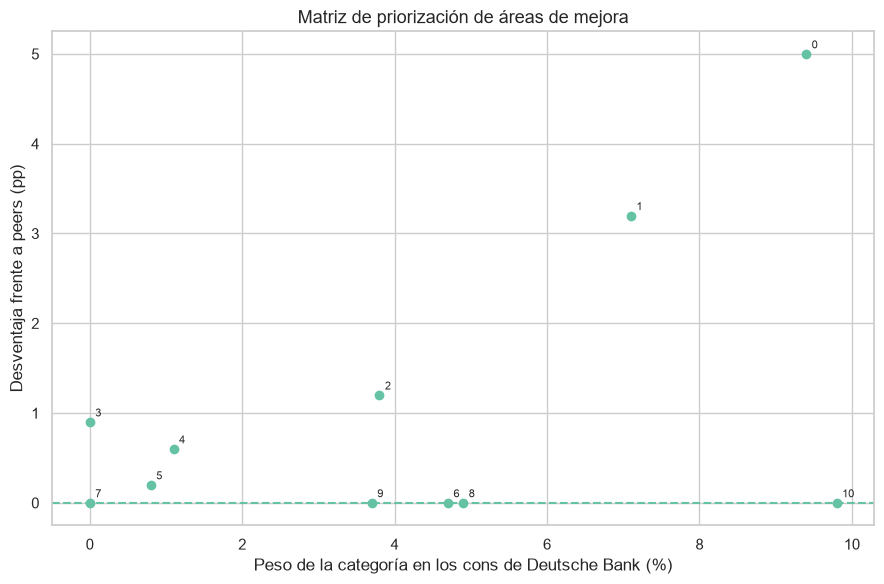

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    priorizacion["Peso cons DB (%)"],
    priorizacion["Desventaja vs peers (pp)"]
)

for categoria, fila in priorizacion.iterrows():
    ax.annotate(
        categoria,
        (
            fila["Peso cons DB (%)"],
            fila["Desventaja vs peers (pp)"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

ax.axhline(0, linestyle="--")
ax.set_xlabel("Peso de la categoría en los cons de Deutsche Bank (%)")
ax.set_ylabel("Desventaja frente a peers (pp)")
ax.set_title("Matriz de priorización de áreas de mejora")

plt.tight_layout()
plt.show()

Las áreas que deberían recibir mayor atención por parte de RRHH son Compensación y beneficios y Carrera y desarrollo, al combinar relevancia interna con una posición peor que la de los competidores. Como tercera línea secundaria aparece Tecnología y herramientas, aunque con una desventaja menor. Por el contrario, la conciliación puede considerarse una fortaleza relativa de Deutsche Bank y un elemento potencialmente aprovechable en employer branding.

**Recomendaciones para RRHH**

A partir de la matriz de priorización, Deutsche Bank debería centrar sus esfuerzos principalmente en tres áreas. En Compensación y beneficios, convendría revisar la competitividad salarial frente al mercado y analizar si determinados perfiles o niveles están quedando por debajo de los peers, complementándolo con una mejor comunicación del paquete total de beneficios.

En Carrera y desarrollo, sería recomendable reforzar los planes de promoción interna, formación y movilidad entre áreas, haciendo más visibles las oportunidades de crecimiento profesional para evitar la percepción de estancamiento.

Como tercera línea, Tecnología y herramientas presenta una desventaja menor pero relevante. Aquí podrían priorizarse mejoras en procesos, sistemas internos y herramientas de trabajo que faciliten el día a día de los empleados.

Al mismo tiempo, Conciliación y carga de trabajo debería mantenerse como fortaleza y aprovecharse en employer branding, ya que Deutsche Bank obtiene una posición claramente mejor que sus competidores en esta dimensión.

Con estas acciones, RRHH podría actuar sobre las debilidades más diferenciales sin descuidar aquellos aspectos que ya funcionan bien y que pueden reforzar la atracción y retención de talento.

**Limitaciones del análisis**

Los resultados deben interpretarse con cautela. Las reseñas de Glassdoor no representan necesariamente a toda la plantilla, ya que participan de forma voluntaria y pueden existir sesgos de selección. Además, el dataset combina empleados de distintos países, áreas y puestos, por lo que algunas diferencias pueden deberse al contexto laboral y no únicamente a la empresa.

Por último, la asignación de topics mediante BERTopic no es perfecta: algunos textos quedan sin tema claro o pueden clasificarse en categorías que no reflejan completamente su significado. Por tanto, los resultados deben entenderse como una herramienta de diagnóstico y priorización, no como una medida exacta de toda la organización.

## 9. Extra: evolución temporal de las principales categorías

Como análisis adicional, se estudia cómo han evolucionado algunas de las principales categorías de queja en Deutsche Bank a lo largo del tiempo.

El objetivo es comprobar si las áreas identificadas previamente como relevantes son problemas persistentes o si han ganado o perdido importancia en los últimos años. Para ello, se comparan dos periodos: 2018-2020 y 2021-2023.

El análisis se centra en tres categorías especialmente relevantes para el diagnóstico: **Compensación y beneficios**, **Carrera y desarrollo** y **Conciliación y carga de trabajo**.

### 9.1 Definición

Para simplificar la comparación, las reseñas de Deutsche Bank se agrupan en dos grandes periodos temporales. Esto permite observar cambios estructurales sin introducir demasiado ruido año a año.

A continuación se calcula el porcentaje de `cons` asociado a cada una de las categorías seleccionadas dentro de cada periodo.
La comparación permite observar si determinadas quejas han aumentado o reducido su presencia relativa con el paso del tiempo.

In [43]:
db_extra = df_nlp[df_nlp["firm"] == "Deutsche-Bank"].copy()

db_extra["periodo"] = np.where(
    db_extra["date_review"].dt.year <= 2020,
    "2018-2020",
    "2021-2023"
)

categorias_extra = [
    "Compensación y beneficios",
    "Carrera y desarrollo",
    "Conciliación y carga de trabajo"
]

temporal_cons = (
    pd.crosstab(
        db_extra["categoria_cons"],
        db_extra["periodo"],
        normalize="columns"
    ) * 100
)

temporal_cons = temporal_cons.loc[
    temporal_cons.index.isin(categorias_extra)
]

display(temporal_cons.style.format("{:.1f}%"))

periodo,2018-2020,2021-2023
categoria_cons,,
Carrera y desarrollo,6.9%,8.4%
Compensación y beneficios,7.7%,10.3%
Conciliación y carga de trabajo,8.7%,10.8%


### 9.2 Cambio entre periodos

Para facilitar la interpretación, se calcula la diferencia en puntos porcentuales entre 2021-2023 y 2018-2020.

Un valor positivo indica que la categoría ha ganado peso entre los `cons` recientes, mientras que un valor negativo indica que su presencia relativa ha disminuido.

In [44]:
temporal_cons["Cambio (pp)"] = (
    temporal_cons["2021-2023"]
    - temporal_cons["2018-2020"]
)

display(
    temporal_cons
    .sort_values("Cambio (pp)", ascending=False)
    .style.format("{:.1f}")
)

periodo,2018-2020,2021-2023,Cambio (pp)
categoria_cons,,,
Compensación y beneficios,7.7,10.3,2.6
Conciliación y carga de trabajo,8.7,10.8,2.1
Carrera y desarrollo,6.9,8.4,1.5


### 9.3 Visualización de la evolución

El gráfico permite comparar visualmente el peso de cada categoría en ambos periodos e identificar rápidamente qué áreas han mejorado o empeorado en términos relativos.

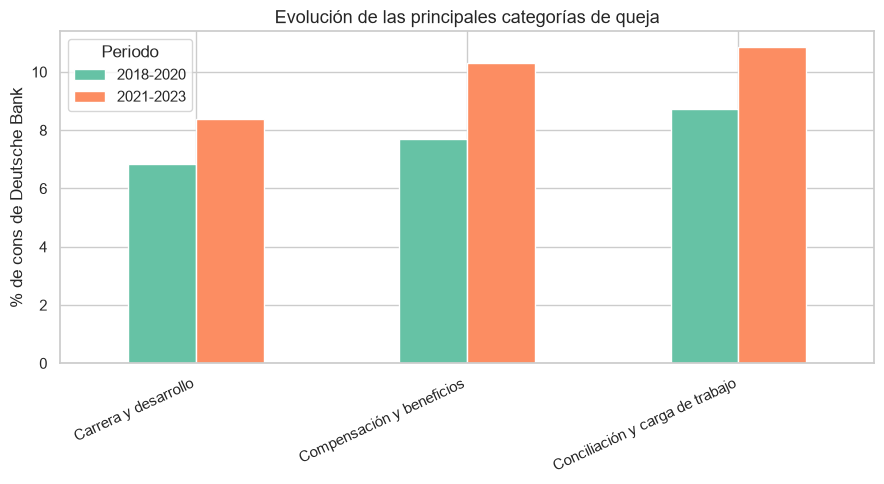

In [45]:
grafico_temporal = (
    temporal_cons[["2018-2020", "2021-2023"]]
    .reset_index()
    .melt(
        id_vars="categoria_cons",
        var_name="Periodo",
        value_name="Porcentaje"
    )
)

import matplotlib.pyplot as plt

pivot_temporal = grafico_temporal.pivot(
    index="categoria_cons",
    columns="Periodo",
    values="Porcentaje"
)

pivot_temporal.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("% de cons de Deutsche Bank")
plt.xlabel("")
plt.title("Evolución de las principales categorías de queja")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Conclusión del análisis temporal**

Las tres categorías analizadas aumentan su presencia entre los `cons` de Deutsche Bank en el periodo 2021-2023. El mayor incremento se observa en Compensación y beneficios, seguido de Conciliación y carga de trabajo y Carrera y desarrollo.

Este resultado refuerza especialmente la atención sobre compensación, ya identificada anteriormente como una debilidad frente a los peers, ya que además parece haber ganado relevancia en los últimos años. En cambio, aunque las quejas sobre conciliación también aumentan, Deutsche Bank continúa presentando una posición relativa mejor que sus competidores en esta dimensión.

## 10. Conclusiones finales

El análisis de las reseñas de Glassdoor permite obtener una visión amplia de la marca empleadora de Deutsche Bank frente a J.P. Morgan, Barclays, Citi y HSBC. Tras revisar la calidad de los datos, no se detectaron problemas relevantes de valores nulos, textos vacíos o duplicados, por lo que la muestra resultó adecuada para continuar con el análisis.

En el EDA, Deutsche Bank presenta el rating medio más bajo del grupo (3,73) y un porcentaje de recomendación del 43,4 %, inferior a la media de los peers. Sin embargo, la evolución temporal es positiva: el rating pasa de 3,40 en 2018 a 3,87 en 2023, reduciendo progresivamente la distancia respecto a los competidores. También se observa que los antiguos empleados puntúan peor que los actuales, una tendencia presente en todas las empresas, aunque Deutsche Bank mantiene una posición desfavorable también dentro de este grupo.

El análisis de sentimiento funcionó como control de calidad y mostró una elevada coherencia entre el contenido de los textos y los campos pros y cons: más del 92 % de los pros fueron clasificados como positivos y alrededor del 79-85 % de los cons como negativos. Las discordancias revisadas se explican en muchos casos por textos ambiguos, comentarios mixtos o usuarios que no utilizan los campos de la forma esperada, por lo que no se consideraron automáticamente errores del modelo.

Mediante BERTopic se identificaron y agruparon los principales temas presentes en las reseñas en categorías relevantes para RRHH. Se mantuvieron los textos sin tema asignado en el análisis para evitar forzar clasificaciones y se revisaron manualmente los topics antes de agruparlos, facilitando una comparación común entre Deutsche Bank y sus competidores.

La comparación con los peers muestra que la principal fortaleza relativa de Deutsche Bank es Conciliación y carga de trabajo, con un balance claramente mejor que el mercado comparable. También aparecen señales favorables en Cultura y relaciones y Procesos y organización. Por el contrario, las principales debilidades relativas son Compensación y beneficios y Carrera y desarrollo, seguidas a mayor distancia por Tecnología y herramientas.

El análisis de empleados actuales y antiguos refuerza parte de este diagnóstico. Entre los antiguos empleados de Deutsche Bank destacan relativamente más las menciones a estabilidad y rotación y compensación, mientras que la conciliación aparece con menos peso que entre los antiguos empleados de los peers. Esto sugiere que los posibles factores de retención diferencial están más relacionados con estabilidad, compensación y desarrollo que con carga de trabajo.

La matriz de priorización confirma que RRHH debería centrar sus esfuerzos principalmente en mejorar la competitividad de la compensación, reforzar las oportunidades de carrera y movilidad interna y revisar herramientas y procesos de trabajo. Al mismo tiempo, la conciliación debería mantenerse y utilizarse como elemento diferencial en employer branding y atracción de talento.

Finalmente, el análisis temporal adicional muestra que las principales categorías de queja han ganado presencia en los últimos años, especialmente Compensación y beneficios, lo que refuerza su prioridad como área de seguimiento. En conjunto, Deutsche Bank no presenta una situación radicalmente distinta a la de sus competidores, pero sí una combinación clara de fortalezas y debilidades sobre las que RRHH puede actuar de forma más focalizada.

Los resultados deben interpretarse teniendo en cuenta las limitaciones de Glassdoor: las reseñas son voluntarias, no representan necesariamente a toda la plantilla, mezclan países, áreas y perfiles distintos, y la asignación automática de topics no es perfecta. Por tanto, el análisis debe entenderse como una herramienta de diagnóstico y priorización que puede orientar decisiones de RRHH, pero no como una medición exhaustiva de toda la experiencia del empleado.

La prioridad para RRHH no es corregir todo lo que aparece en las reseñas, sino actuar donde Deutsche Bank está peor que el mercado: principalmente compensación y desarrollo profesional, preservando la conciliación como ventaja competitiva.

In [46]:
fin_notebook = time.perf_counter()

tiempo_total = fin_notebook - inicio_notebook

print(f"Tiempo total: {tiempo_total/60:.2f} minutos")

Tiempo total: 9.06 minutos
